# General functions

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import seaborn as sns

from paper.models import KthEigval, KthEigval1DMonotone
from paper.synth_fn import random_func, random_inc_func
from paper.training import Synthetic1DStream, compute_scaling_law
from paper.plotting import func_gallery

mpl.rcParams['figure.dpi'] = 140

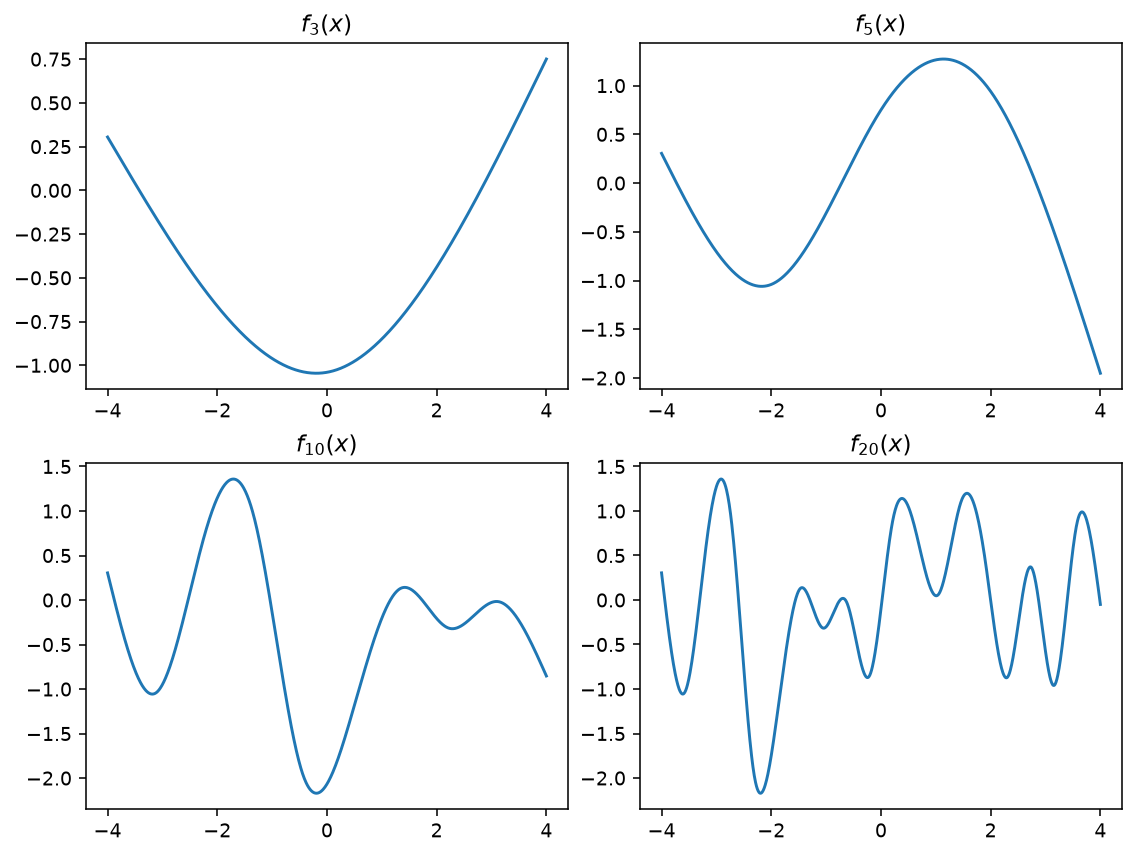

In [2]:
func_gallery(random_func)
plt.show()

In [5]:
dims = [3, 5, 10]
complexities = [3, 5, 10, 20]
scaling_laws = []
for complexity in complexities:
    for dim in dims:
        scaling_law = compute_scaling_law(
            Synthetic1DStream(random_func(complexity)),
            lambda: KthEigval(1, dim)
        )
        scaling_law['dim'] = dim
        scaling_law['complexity'] = complexity
        scaling_laws.append(scaling_law.reset_index())
        print(f'Computed dim={dim}, complexity={complexity}')

Computed dim=3, complexity=3
Computed dim=5, complexity=3
Computed dim=10, complexity=3
Computed dim=3, complexity=5
Computed dim=5, complexity=5
Computed dim=10, complexity=5
Computed dim=3, complexity=10
Computed dim=5, complexity=10
Computed dim=10, complexity=10
Computed dim=3, complexity=20
Computed dim=5, complexity=20
Computed dim=10, complexity=20


In [8]:
scaling_laws_df = pd.concat(scaling_laws, axis=0)

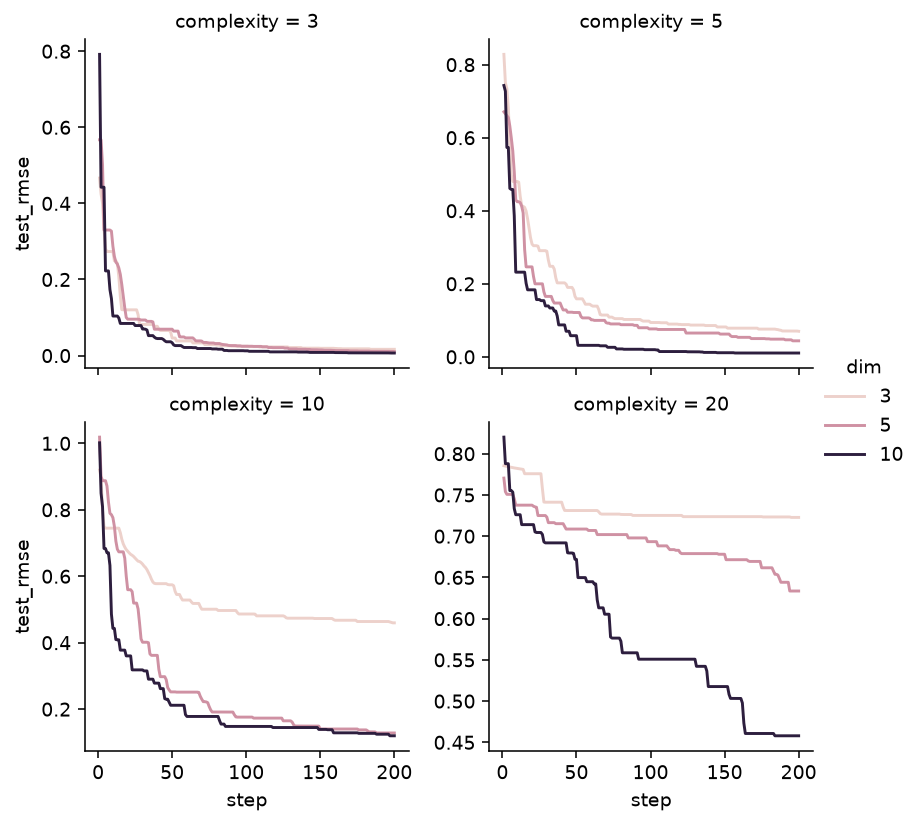

In [11]:
sns.relplot(scaling_laws_df, kind='line', x='step', y='test_rmse', col='complexity', hue='dim', 
            col_wrap=2, height=3, facet_kws={'sharey': False, 'sharex': True})

# Monotone functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import seaborn as sns

from paper.models import KthEigval, KthEigval1DMonotone
from paper.synth_fn import random_func, random_inc_func
from paper.training import Synthetic1DStream, compute_scaling_law
from paper.plotting import func_gallery

mpl.rcParams['figure.dpi'] = 140

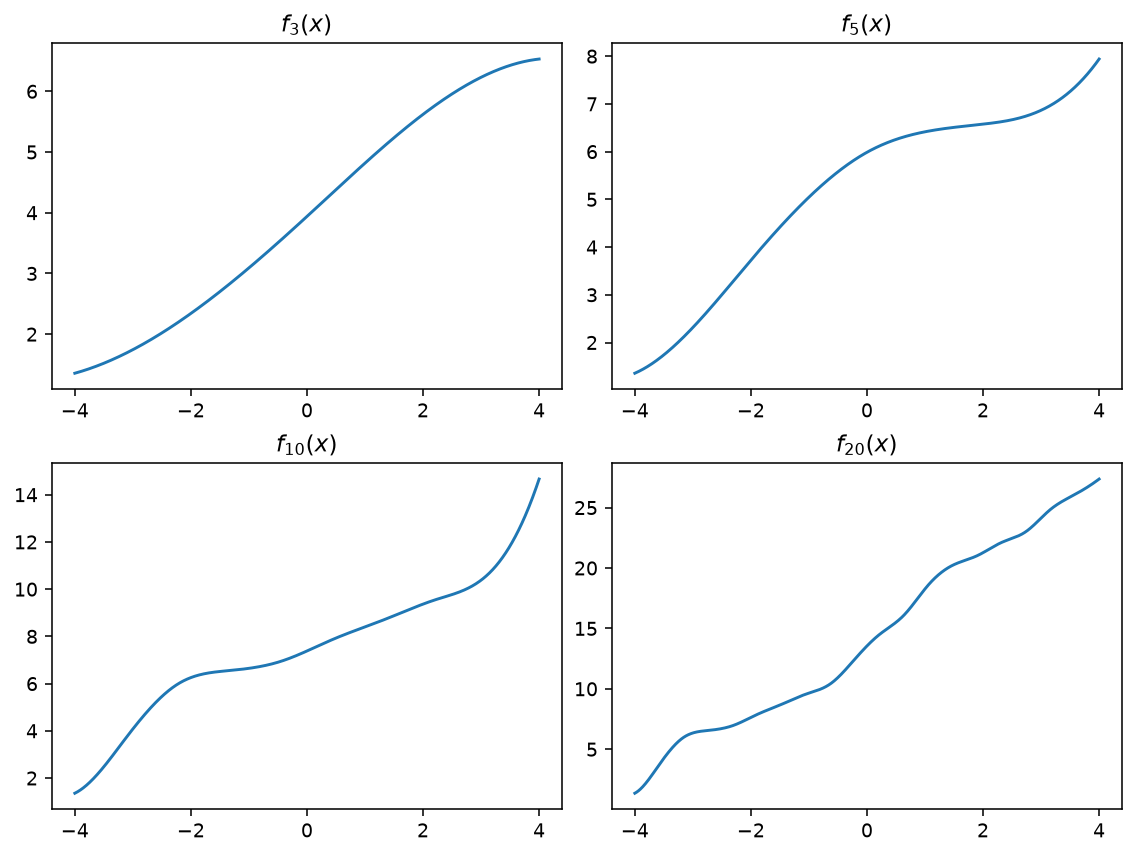

In [2]:
func_gallery(random_inc_func)
plt.show()

In [8]:
dims = [3, 5, 10]
complexities = [5, 10, 20]
noise_stds = [0, 1e-1]
scaling_laws = []
for complexity in complexities:
    for dim in dims:
        for noise_std in noise_stds:
            scaling_law = compute_scaling_law(
                Synthetic1DStream(random_inc_func(complexity), noise_std=noise_std),
                lambda: KthEigval1DMonotone(dim)
            )
            scaling_law['dim'] = dim
            scaling_law['complexity'] = complexity
            scaling_law['kind'] = 'monotone'
            scaling_law['noise_std'] = noise_std
            scaling_laws.append(scaling_law.reset_index())
            print(f'Computed dim={dim}, complexity={complexity}, noise_std={noise_std}, kind = monotone')
            
            scaling_law = compute_scaling_law(
                Synthetic1DStream(random_inc_func(complexity), noise_std=noise_std),
                lambda: KthEigval(1, dim)
            )
            scaling_law['dim'] = dim
            scaling_law['complexity'] = complexity
            scaling_law['kind'] = 'generic'
            scaling_law['noise_std'] = noise_std
            scaling_laws.append(scaling_law.reset_index())
            print(f'Computed dim={dim}, complexity={complexity}, noise_std={noise_std}, kind = generic')

Computed dim=3, complexity=5, noise_std=0, kind = monotone
Computed dim=3, complexity=5, noise_std=0, kind = generic
Computed dim=3, complexity=5, noise_std=0.1, kind = monotone
Computed dim=3, complexity=5, noise_std=0.1, kind = generic
Computed dim=5, complexity=5, noise_std=0, kind = monotone
Computed dim=5, complexity=5, noise_std=0, kind = generic
Computed dim=5, complexity=5, noise_std=0.1, kind = monotone
Computed dim=5, complexity=5, noise_std=0.1, kind = generic
Computed dim=10, complexity=5, noise_std=0, kind = monotone
Computed dim=10, complexity=5, noise_std=0, kind = generic
Computed dim=10, complexity=5, noise_std=0.1, kind = monotone
Computed dim=10, complexity=5, noise_std=0.1, kind = generic
Computed dim=3, complexity=10, noise_std=0, kind = monotone
Computed dim=3, complexity=10, noise_std=0, kind = generic
Computed dim=3, complexity=10, noise_std=0.1, kind = monotone
Computed dim=3, complexity=10, noise_std=0.1, kind = generic
Computed dim=5, complexity=10, noise_std

In [9]:
scaling_laws_df = pd.concat(scaling_laws, axis=0)

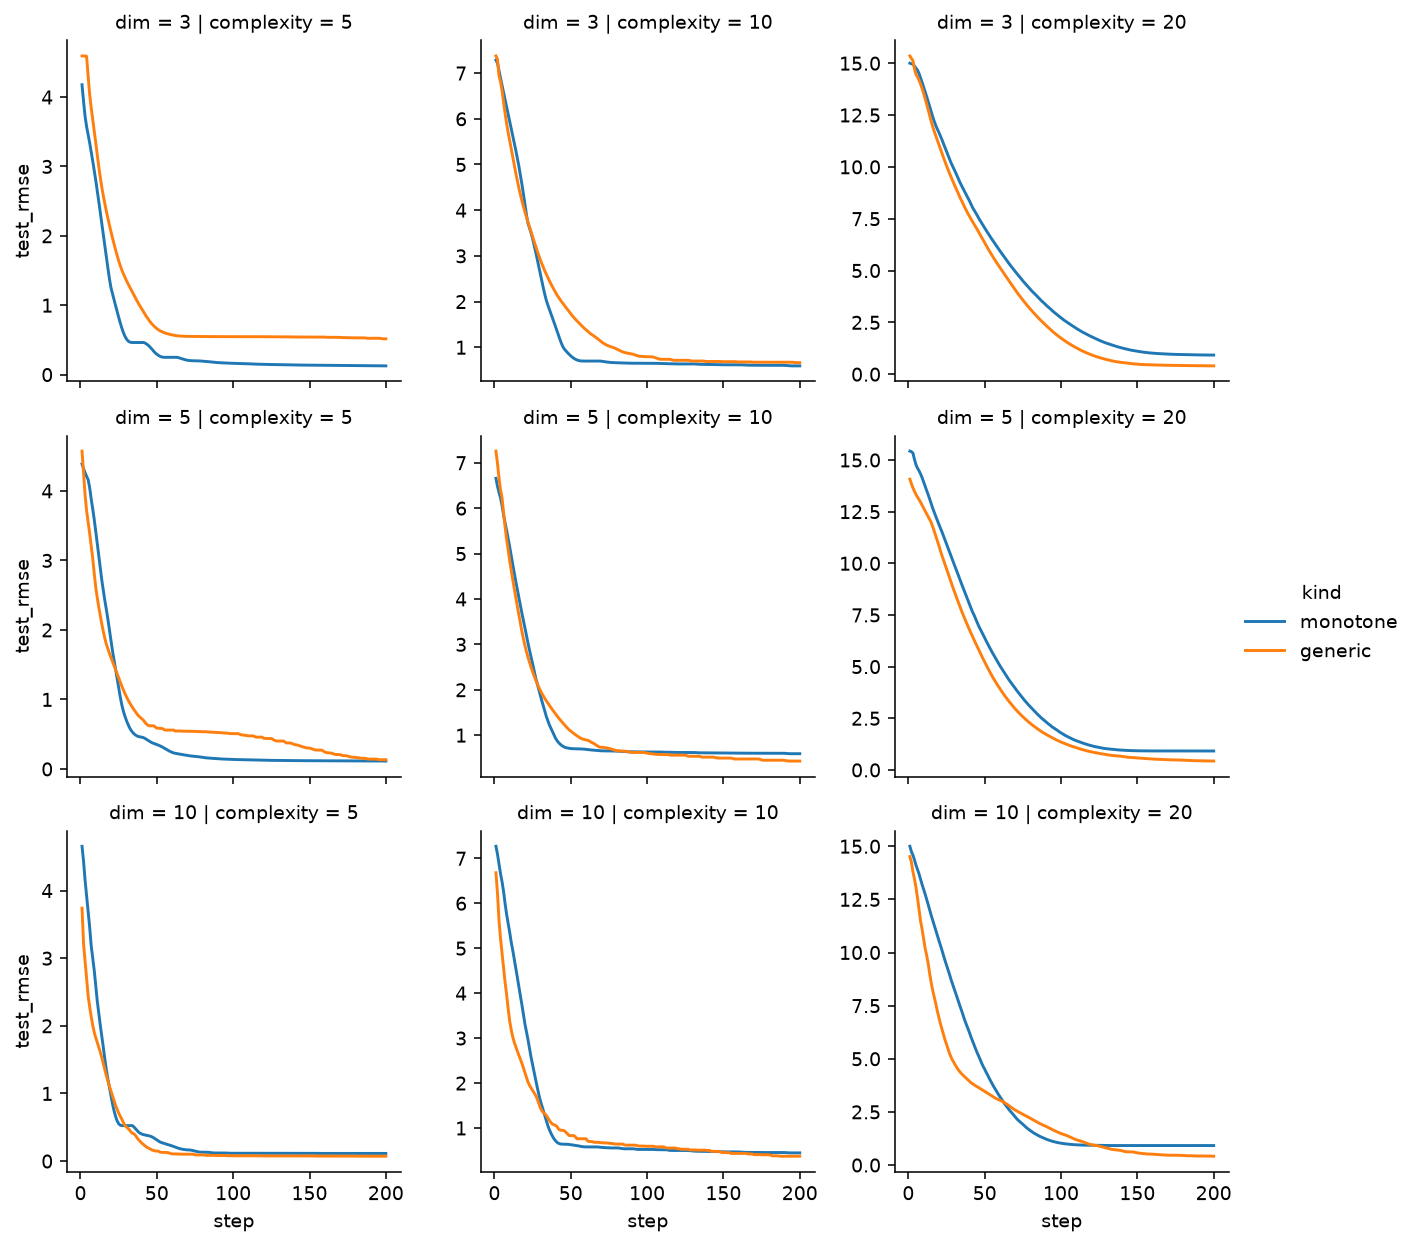

In [5]:
sns.relplot(scaling_laws_df[scaling_laws_df['noise_std'] == 0], kind='line', x='step', y='test_rmse', row='dim', col='complexity', hue='kind', 
            height=3, facet_kws={'sharey': False, 'sharex': True})

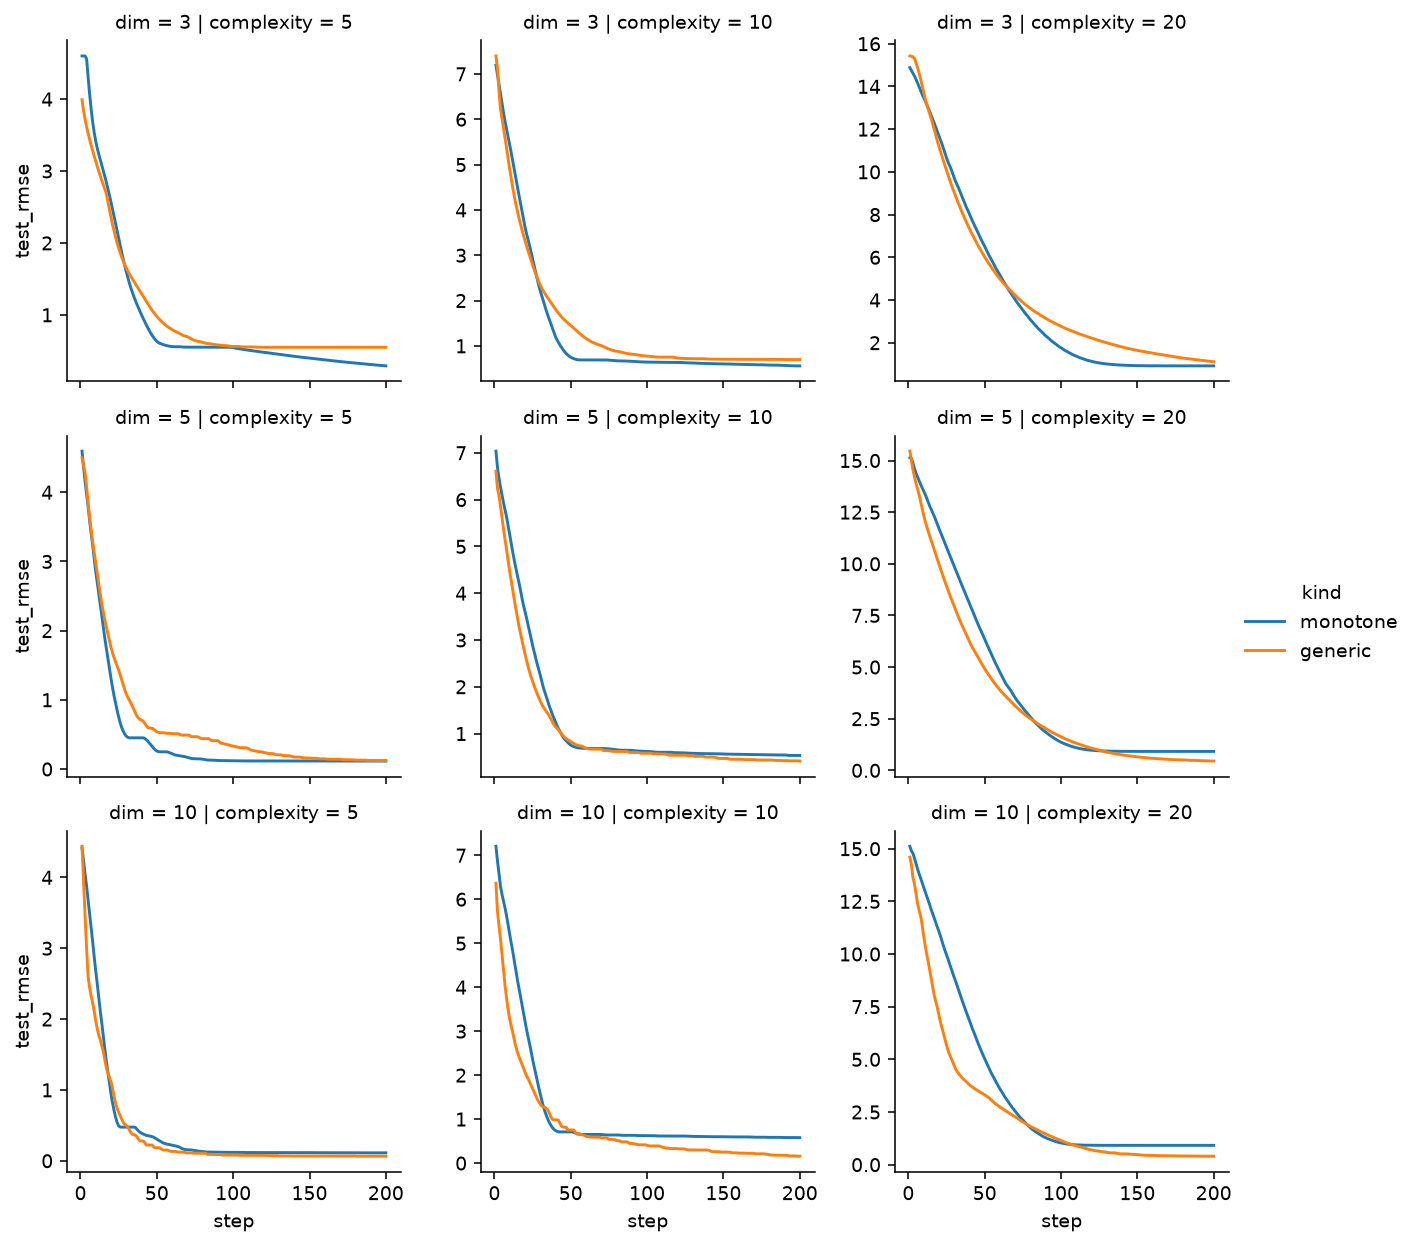

In [10]:
sns.relplot(scaling_laws_df[scaling_laws_df['noise_std'] > 0], kind='line', x='step', y='test_rmse', row='dim', col='complexity', hue='kind', 
            height=3, facet_kws={'sharey': False, 'sharex': True})